Pre processing dei dati


In [1]:
import torch
import numpy as np
np.random.seed(1122)
torch.cuda.random.manual_seed(1122)
print(torch.cuda.is_available())

True


In [2]:
path_dataset = "../dataset/food11"
path_modelli = "../modelli"
path_logs = "../logs_food11"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

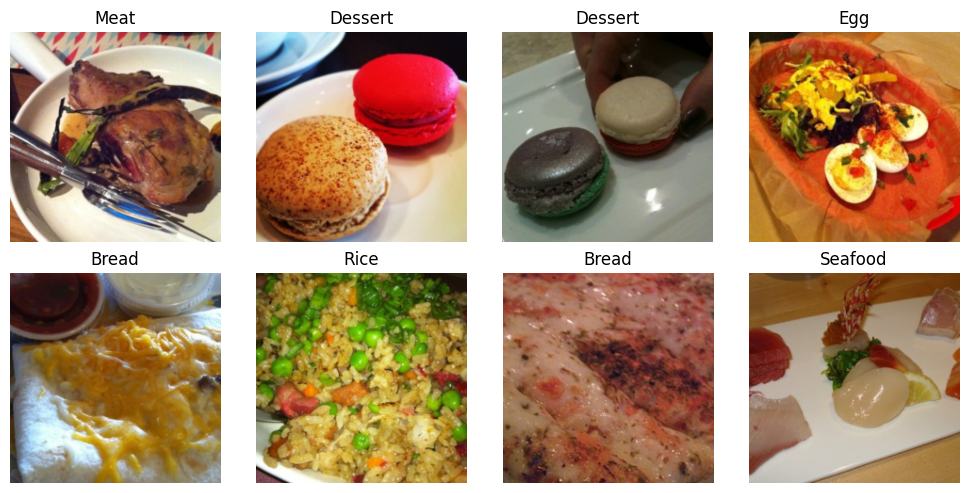

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "training"),
    transform = transform_train
)


train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=0, pin_memory=True)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for img, label, ax in zip(images[:8], labels[:8], axes):
    
    # Da (C, H, W) → (H, W, C)
    img = img.permute(1, 2, 0)
    ax.imshow(img)
    
    class_name = train_dataset.classes[label]
    ax.set_title(f"{class_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [4]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),      
    transforms.RandomHorizontalFlip(),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


from torch.utils.data import Dataset
from PIL import Image

class FoodDataset(Dataset):
    def __init__(self, root, weak_classes, light_transform, strong_transform):
        # ImageFolder solo per recuperare paths e labels
        base_dataset = datasets.ImageFolder(root=root)
        self.samples = base_dataset.samples
        self.class_to_idx = base_dataset.class_to_idx
        self.classes = base_dataset.classes
        self.targets = base_dataset.targets
        # map delle classi 'deboli' in indici
        self.weak_class_indices = {self.class_to_idx[cls] for cls in weak_classes}

        self.light_transform = light_transform
        self.strong_transform = strong_transform



    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")

        # augmentation diversa in base alla classe
        if label in self.weak_class_indices:
            image = self.strong_transform(image)
        else:
            image = self.light_transform(image)

        return image, label

    def __len__(self):
        return len(self.samples)



# Creiamo i dataset per training, evaluation e validation

train_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "training"),
    transform=transform_train
)
"""
train_dataset = FoodDataset(
    root=os.path.join(path_dataset, "training"),
    weak_classes=['Bread', 'Egg', 'Dairy product'],
    light_transform=transform_train,
    strong_transform=strong_transform
)
"""

val_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "validation"),
    transform=transform_test
)

# da creare quando i dati di test saranno pronti
"""
test_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "test"),
    transform=transform_test
)
"""

class_names = train_dataset.classes
print("Classi trovate:",class_names )

# Creazione dei data loader
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=0, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size= 32, shuffle=False,num_workers= 2, pin_memory=True)

#test_loader = DataLoader(test_dataset, batch_size= 32, shuffle=False,num_workers=0,pin_memory=True)



Classi trovate: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']


In [5]:
from collections import Counter

def count_images_per_class(dataset, dataset_name):
    tot = 0
    counter = Counter(dataset.targets)
    print(f"Distribuzione nel dataset {dataset_name}:")
    for class_idx, num_images in sorted(counter.items()):
        class_name = dataset.classes[class_idx]
        tot +=  num_images
        print(f" - Classe '{class_name}': {num_images} immagini")
    print(f"Totale immagini nel dataset {dataset_name} = {tot}")
    print()

# Calcola distribuzioni sui tre dataset
count_images_per_class(train_dataset, "Training")
#count_images_per_class(test_dataset, "Evaluation")
count_images_per_class(val_dataset, "Validation")

Distribuzione nel dataset Training:
 - Classe 'Bread': 1362 immagini
 - Classe 'Dairy product': 577 immagini
 - Classe 'Dessert': 2000 immagini
 - Classe 'Egg': 1321 immagini
 - Classe 'Fried food': 1135 immagini
 - Classe 'Meat': 1757 immagini
 - Classe 'Noodles-Pasta': 587 immagini
 - Classe 'Rice': 376 immagini
 - Classe 'Seafood': 1158 immagini
 - Classe 'Soup': 2000 immagini
 - Classe 'Vegetable-Fruit': 940 immagini
Totale immagini nel dataset Training = 13213

Distribuzione nel dataset Validation:
 - Classe 'Bread': 362 immagini
 - Classe 'Dairy product': 144 immagini
 - Classe 'Dessert': 500 immagini
 - Classe 'Egg': 327 immagini
 - Classe 'Fried food': 326 immagini
 - Classe 'Meat': 449 immagini
 - Classe 'Noodles-Pasta': 147 immagini
 - Classe 'Rice': 96 immagini
 - Classe 'Seafood': 347 immagini
 - Classe 'Soup': 500 immagini
 - Classe 'Vegetable-Fruit': 232 immagini
Totale immagini nel dataset Validation = 3430



In [6]:
# Salvataggio in csv (es. training)
"""
import csv

csv_path = path_dataset + "train_dataset.csv"

# Le righe hanno la struttura: [path_immagine, label, nome_classe]
with open(csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["image_path", "label", "class_name"])  # intestazione

    for path, label in train_dataset.samples:
        class_name = train_dataset.classes[label]
        writer.writerow([path, label, class_name])

print(f"CSV salvato in {csv_path}")
"""

'\nimport csv\n\ncsv_path = path_dataset + "train_dataset.csv"\n\n# Le righe hanno la struttura: [path_immagine, label, nome_classe]\nwith open(csv_path, mode=\'w\', newline=\'\') as csv_file:\n    writer = csv.writer(csv_file)\n    writer.writerow(["image_path", "label", "class_name"])  # intestazione\n\n    for path, label in train_dataset.samples:\n        class_name = train_dataset.classes[label]\n        writer.writerow([path, label, class_name])\n\nprint(f"CSV salvato in {csv_path}")\n'

Procedure di train, test e valutazione


In [7]:
class AverageValueMeter():
  def __init__(self):
    self.reset()

  def reset(self):
    self.sum = 0
    self.num = 0

  def add(self,value,num):
    self.sum += value*num
    self.num += num

  def value(self):
    try:
      return self.sum/self.num
    except:
      return None

In [ ]:
# procedura di training 
from torch.optim import SGD
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, f1_score
from os.path import join
import torch.nn as nn


def train_classifier(model, train_loader, val_loader, exp_name = 'experiment', lr = 0.01, epochs = 10, momentum = 0.99, criterion = None, weight_decay = 0.0001, logdir = 'logs'):
  
  # funzione di loss
  if criterion is None:
    criterion = nn.CrossEntropyLoss() 
  else:
    criterion = criterion
 
  optimizer = SGD(model.parameters(), lr, momentum = momentum, weight_decay = weight_decay) # funzione di learning

  loss_meter = AverageValueMeter()
  acc_meter = AverageValueMeter()

  # writer
  writer = SummaryWriter(join(path_logs,exp_name))

  # device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model.to(device)

  # definiamo un dizionario contenente i loader di training e test
  loader = {
      'train': train_loader,
      'val': val_loader
  }

  # inizializziamo il global step
  global_step = 0
  
  # inizializzaimo la best acc e la corrispondente epoca
  best_acc = 0
  best_epoch = 0

  for e in range(epochs):
    print(f"Epoch: {e+1} of {epochs}")
    # iteriamo tra due modalità: train e test
    for mode in ['train','val']:
      loss_meter.reset()
      acc_meter.reset()
      model.train() if mode == 'train' else model.eval()

      # per macro f1 score
      all_preds = []
      all_labels = []

      with torch.set_grad_enabled(mode == 'train'): # abilitiamo i gradienti in training
        for i, batch in enumerate(loader[mode]):
          x = batch[0].to(device) #portiamoli sul device corretto
          y = batch[1].to(device)
          output = model(x)

          # aggiorniamo il global_step
          # conterrà il numero di campioni visti durante il training
          n = x.shape[0]
          global_step += n
          l = criterion(output,y)
          
          if mode == 'train':
            l.backward()
            optimizer.step()
            optimizer.zero_grad()

          # parte per macro f1 score
          preds = output.max(1)[1].cpu()
          labels = y.cpu()

          all_preds.extend(preds.numpy())
          all_labels.extend(labels.numpy())

          acc = accuracy_score(y.to('cpu'),output.to('cpu').max(1)[1])
          loss_meter.add(l.item(),n)
          acc_meter.add(acc,n)

          # loggiamo i risultati iterazione per iterazione solo durante il training
          if mode == 'train':
            writer.add_scalar('loss/train', loss_meter.value(), global_step = global_step)
            writer.add_scalar('accuracy/train', acc_meter.value(), global_step = global_step)


      # Calcolo macro F1 a fine epoca
      macro_f1 = f1_score(all_labels, all_preds, average='macro')


      # una volta finita l'epoca (sia nel caso di training che test, loggiamo le stime finali)
      acc = acc_meter.value()
      writer.add_scalar('loss/'+mode, loss_meter.value(), global_step = global_step)
      writer.add_scalar('accuracy/'+mode, acc, global_step = global_step)
      writer.add_scalar(f'macro_f1/{mode}', macro_f1, global_step=global_step)

      # best accuracy
      if mode == 'val' and acc > best_acc:
        best_acc = acc
        best_epoch = e + 1
        print(f"Miglioramento sul val: accuracy  = {best_acc} all'epoca {best_epoch}")
        # conserviamo i pesi quando miglioriamo
        #os.makedirs(path_modelli + "/%s" %(exp_name), exist_ok=True)
        #torch.save(model.state_dict(),path_modelli + '/%s/%s-%d.pth' % (exp_name,exp_name,e+1))
      
      # conserviamo i pesi del modello alla fine di ogni epoca
      os.makedirs(path_modelli + "/%s" %(exp_name), exist_ok=True)
      torch.save(model.state_dict(),path_modelli + '/%s/%s-%d.pth' % (exp_name,exp_name,e+1))
  #torch.save(model.state_dict(), path_modelli + f"{exp_name}-{e+1}.pth")

  return model

In [9]:
# funzione per ottenere le predizione del modello
def test_classifier(model, loader):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  model.eval()
  predictions, labels = [],[]
  for batch in loader:
    x = batch[0].to(device)
    y = batch[1].to(device)
    output = model(x)
    preds = output.to("cpu").max(1)[1].numpy() # le funzioni numpy girano solo su cpu
    labs = y.to("cpu").numpy()
    predictions.extend(list(preds))
    labels.extend(list(labs))
  return np.array(predictions), np.array(labels)

In [10]:
# stampa della matrice di confusione
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm,class_names):
    plt.figure(figsize=(12,8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    n_classes = cm.shape[0]
    if class_names is not None:
        ticks = np.arange(n_classes)
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
    else:
        plt.xlabel('Predicted label')
        plt.ylabel('True label')

    plt.tight_layout()
    plt.show()


In [11]:
from sklearn.metrics import (classification_report,confusion_matrix)

def evaluate_classifier(y_pred, y_true, class_names=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print("=== Classification Report ===")
    print(report)
    print("=== Matrice di confusione ===")
    print(cm)
    plot_confusion_matrix(cm_norm,class_names)
    return report,cm


Squeezenet



In [12]:
# Funzione che adatta il modello squeezenet al mio specifico task

from torch import nn
from torchvision.models import squeezenet1_0
from torchvision.models import SqueezeNet1_0_Weights

def get_squeezenet_model():
  model = squeezenet1_0(weights = SqueezeNet1_0_Weights)
  model.classifier[1] = nn.Conv2d(512,11,kernel_size = (1,1), stride = (1,1))
  model.num_classes = 11
  return model

squeezenet = get_squeezenet_model()

c:\Users\giova\Documents\Università\Machine learning\machine_learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco classifier

def freeze_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [14]:
# Funzione che sblocca tutti i layer -> allenare tutto il modello

def unfreeze_all_layers(model):
    
    for param in model.parameters():
        param.requires_grad = True
    
    return model

In [15]:
# Funzione per stampare quali layer sono bloccati e quali sono allenabili 

def print_trainable_layers(model):
    
    for name, param in model.named_parameters():
        status = "Trainable" if param.requires_grad else "Frozen"
        print(f"{name}: {status}")


In [16]:
def test_squeezenet_with_frozen_features(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_squeezenet_model()
    model = freeze_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)


In [17]:
def test_squeezenet_with_all_layers_trainable(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_squeezenet_model()
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

Training e valutazione su squeezenet con layer di estrazione delle features congelati

In [18]:
# lr = 0.001
# test_squeezenet_with_frozen_features(train_loader, val_loader, exp_name = "squeezenet_frozen_features_lr=0.001", epochs = 30, lr=0.001)

# lr = 0.0001
# test_squeezenet_with_frozen_features(train_loader, val_loader, exp_name = "squeezenet_frozen_features_lr=0.0001", epochs = 30, lr=0.0001)


Training e valutazione su squeezenet con tutti i layer allenabili


In [19]:
# lr = 0.01
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.01", epochs = 30, lr=0.01)

# lr = 0.001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.001", epochs = 30, lr=0.001)

# lr = 0.0001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001", epochs = 30, lr=0.0001)

# lr = 0.0001 e weight decay = 0.00001
# test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001_weightDecay=0.00001", epochs = 30, lr=0.0001, weight_decay=0.00001)


# lr = 0.0001 con weighted loss (bread, dairy product, dessert)
"""
weights = torch.ones(11).cuda()
weights[1] = 2.0
weights[0] = 1.5
weights[2] = 1.5
criterion = nn.CrossEntropyLoss(weight=weights)
test_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001_weighted loss", epochs = 30, lr=0.0001, criterion = criterion)
"""



'\nweights = torch.ones(11).cuda()\nweights[1] = 2.0\nweights[0] = 1.5\nweights[2] = 1.5\ncriterion = nn.CrossEntropyLoss(weight=weights)\ntest_squeezenet_with_all_layers_trainable(train_loader, val_loader, exp_name = "squeezenet_all_layers_trainable_lr=0.0001_weighted loss", epochs = 30, lr=0.0001, criterion = criterion)\n'

Resnet

In [20]:
# funzione che adatta il modello resnet al mio specifico task
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights 

def get_resnet_model():
    model = resnet18(weights = ResNet18_Weights.DEFAULT)
    num_classes = 11
    model.fc = nn.Linear(512, num_classes)
    model.num_classes = num_classes
    return model

In [21]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco fc

def freeze_resnet_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [22]:
def test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_resnet_model()
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

In [23]:
def test_resnet_with_frozen_features(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_resnet_model()
    model = freeze_resnet_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)


In [24]:
# Test con data augmentation mirata
from torch.utils.data import Dataset
from PIL import Image

class FoodDataset(Dataset):
    def __init__(self, root, weak_classes, light_transform, strong_transform):
        # ImageFolder solo per recuperare paths e labels
        base_dataset = datasets.ImageFolder(root=root)
        self.samples = base_dataset.samples
        self.class_to_idx = base_dataset.class_to_idx
        self.classes = base_dataset.classes
        self.targets = base_dataset.targets
        # map delle classi 'deboli' in indici
        self.weak_class_indices = {self.class_to_idx[cls] for cls in weak_classes}

        self.light_transform = light_transform
        self.strong_transform = strong_transform



    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")

        # augmentation diversa in base alla classe
        if label in self.weak_class_indices:
            image = self.strong_transform(image)
        else:
            image = self.light_transform(image)

        return image, label

    def __len__(self):
        return len(self.samples)


def test_with_strong_data_augmentation(exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    light_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),      
        transforms.RandomHorizontalFlip(),    
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    strong_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    transform_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # Creiamo i dataset per training, evaluation e validation
    """
    train_dataset = datasets.ImageFolder(
        root=os.path.join(path_dataset, "training"),
        transform=transform_train
    )
    """

    train_dataset = FoodDataset(
        root=os.path.join(path_dataset, "training"),
        weak_classes=['Bread', 'Egg', 'Dairy product'],
        light_transform=light_transform,
        strong_transform=strong_transform
    )

    val_dataset = datasets.ImageFolder(
        root=os.path.join(path_dataset, "validation"),
        transform=transform_test
    )

    # Creazione dei data loader
    train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size= 32, shuffle=False,num_workers= 2, pin_memory=True)
    
    # Parte il test con i nuovi data loader 
    test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = exp_name,epochs = epochs,lr = lr, weight_decay = weight_decay)


Training e valutazione su resnet con layer di estrazione delle features congelati

In [25]:
# test_resnet_with_frozen_features(train_loader,val_loader,"resnet_frozen_features_lr=0.0001",30,lr = 0.0001)


Training e valutazione su resnet con fine tuning dell'intera rete


In [26]:
# test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "resenet_all_layers_lr=0.0001",epochs = 30,lr = 0.0001)
# test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "resnet_all_layers_lr=0.00001",epochs = 30,lr = 0.00001)
# test_resnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "resnet_all_layers_weightDecay=0_lr=0.0001",epochs = 30,lr = 0.0001, weight_decay = 0):


# test_with_strong_data_augmentation(exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):


In [27]:
"""
model = get_resnet_model()
model.load_state_dict(torch.load("../modelli/resnet_frozen_features_lr=0.0001/resnet_frozen_features_lr=0.0001-21.pth", map_location=device))
y_pred, y_true = test_classifier(model, val_loader)
evaluate_classifier(y_pred, y_true, class_names)
"""

'\nmodel = get_resnet_model()\nmodel.load_state_dict(torch.load("../modelli/resnet_frozen_features_lr=0.0001/resnet_frozen_features_lr=0.0001-21.pth", map_location=device))\ny_pred, y_true = test_classifier(model, val_loader)\nevaluate_classifier(y_pred, y_true, class_names)\n'

EfficientNet

In [28]:
# Funzione che adatta EfficientNet al mio specifico task
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

def get_efficientnet_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(1280, 11)
    return model


In [29]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco classifier

def freeze_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [30]:
# Funzione che sblocca tutti i layer -> allenare tutto il modello

def unfreeze_all_layers(model):
    
    for param in model.parameters():
        param.requires_grad = True
    
    return model

In [31]:
def test_efficientnet_with_frozen_features(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_efficientnet_model()
    model = freeze_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

In [32]:
def test_efficientnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "experiment",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None):
    model = get_efficientnet_model()
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)

In [33]:
# test_efficientnet_with_all_layers_trainable(train_loader,val_loader,exp_name = "prova",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None)
   

In [34]:
# provando a refactorizzare il codice

def test_experiment(name_model, train_loader, val_loader, fine_tuning_all_layers = True, exp_name = "prova",epochs = 30,lr = 0.0001, weight_decay = 0.0001, criterion = None ):
    # inizializzazione del modello
    name_model = name_model.lower()
    if name_model == 'squeeznet':
         model = get_squeezenet_model()
    elif name_model == 'resnet':
         model = get_resnet_model()
    elif name_model == 'efficientnet':
         model = get_efficientnet_model()
    else: 
         print("Il nome del modello inserito è errato")
         return
    
    # allenare l'intera rete o solo il classificatore
    if not fine_tuning_all_layers :
         if name_model == 'resnet':
              freeze_resnet_features(model)
         else:
              freeze_features(model)
    else:
         unfreeze_all_layers(model)
     
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs, weight_decay = weight_decay, criterion = criterion)
    y_pred, y_true = test_classifier(model, val_loader)
    evaluate_classifier(y_pred, y_true, class_names)
         

In [89]:
model = get_resnet_model()
model.load_state_dict(torch.load(path_modelli + "/resnet_all_layers_lr=0.0001/resnet_all_layers_lr=0.0001-29.pth", map_location=device))
model.eval()
img = Image.open(path_dataset + "/test/image.png").convert("RGB")

# Trasforma
img_tensor = transform_test(img).unsqueeze(0)  # aggiunge batch dimension

img_tensor = img_tensor.to(device)
model.to(device)
with torch.no_grad():
    output = model(img_tensor)
    # preds = output.to("cpu").max(1)[1].numpy()
    probabilities = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

print(f"Classe predetta = {class_names[predicted_class]}")


Classe predetta = Meat


Epoch: 1 of 1
step =  32
step =  64
step =  96
step =  128
step =  160
step =  192
step =  224
step =  256
step =  288
step =  320
step =  352
step =  384
step =  416
step =  448
step =  480
step =  512
step =  544
step =  576
step =  608
step =  640
step =  672
step =  704
step =  736
step =  768
step =  800
step =  832
step =  864
step =  896
step =  928
step =  960
step =  992
step =  1024
step =  1056
step =  1088
step =  1120
step =  1152
step =  1184
step =  1216
step =  1248
step =  1280
step =  1312
step =  1344
step =  1376
step =  1408
step =  1440
step =  1472
step =  1504
step =  1536
step =  1568
step =  1600
step =  1632
step =  1664
step =  1696
step =  1728
step =  1760
step =  1792
step =  1824
step =  1856
step =  1888
step =  1920
step =  1952
step =  1984
step =  2016
step =  2048
step =  2080
step =  2112
step =  2144
step =  2176
step =  2208
step =  2240
step =  2272
step =  2304
step =  2336
step =  2368
step =  2400
step =  2432
step =  2464
step =  2496
step =

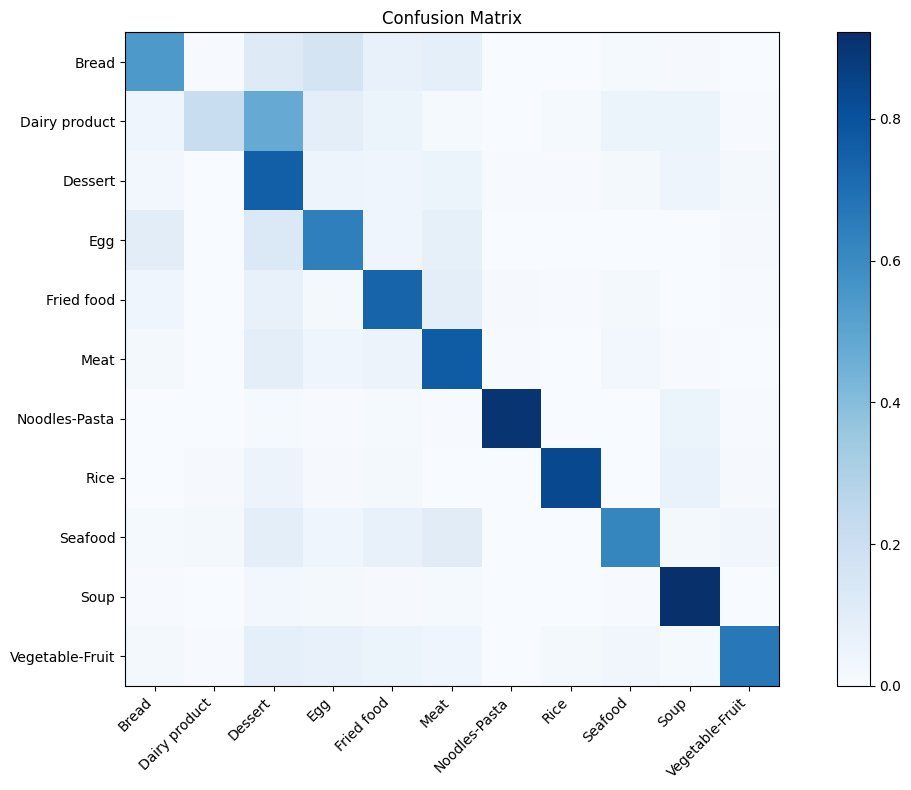

In [35]:
test_experiment('resnet',train_loader,val_loader,fine_tuning_all_layers=False,exp_name="Prova",epochs = 1, lr = 0.0001)